# Converting a mesh between formats with meshio++ (C++ / xeus-cpp)

C++ counterpart of
[`02_convert_and_inspect.ipynb`](../example/02_convert_and_inspect.ipynb).
meshio++'s registry (`registry.hpp`) dispatches to any of its 35+ format
writers from one table; here we take the bracket geometry, write it to
several formats, compare sizes, and verify every round trip.

Two format-specific notes that only matter because this is a pure-C++,
no-Python-fallback kernel: the registry's default *writer* table
(`registry_writers()`) bakes in `zlib`-compressed VTU/VTP, and this
notebook's amalgamated core is built with no optional deps
(`MESHIOPLUSPLUS_HAS_ZLIB` undefined) — so VTU is written directly via
`write_vtu(path, mesh, binary, /*zlib=*/false)` instead of through the
registry table. XDMF's data format also depends on the build
(`MESHIOPLUSPLUS_HAS_HDF5`); with neither optional dep it falls back to
inline XML, which is what `write_xdmf(path, mesh, "XML")` requests
explicitly.

In [ ]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
#include <iomanip>
#include <cmath>
#include <algorithm>
#include <numeric>
#include <random>
#include <chrono>

#ifndef M_PI
#define M_PI 3.14159265358979323846
#endif

using namespace meshioplusplus;
using namespace mio_nb;

In [2]:
Mesh mesh = registry_read("example.vtu", resolve_format("example.vtu", ""), {});
std::cout << mesh.NumPoints() << " points, " << mesh.Cells(0).NumCells() << " triangles, "
          << mesh.Cells(1).NumCells() << " tetrahedra\n";

52282 points, 58394 triangles, 235014 tetrahedra


## Convert to several formats

In [3]:
#include <filesystem>

std::filesystem::path tmpdir = std::filesystem::temp_directory_path() / "meshioplusplus_cpp_convert";
std::filesystem::create_directories(tmpdir);

struct Target { std::string label; std::string path; std::string format; };
std::vector<Target> targets = {
    {"vtu (ascii)",  (tmpdir / "mesh_ascii.vtu").string(), "vtu"},
    {"vtu (binary)", (tmpdir / "mesh.vtu").string(),       "vtu"},
    {"vtk (binary)", (tmpdir / "mesh.vtk").string(),       "vtk"},
    {"xdmf",         (tmpdir / "mesh.xdmf").string(),      "xdmf"},
    {"gmsh (binary)",(tmpdir / "mesh.msh").string(),       "gmsh"},
    {"ply (binary)", (tmpdir / "mesh.ply").string(),       "ply"},
};

write_vtu(targets[0].path, mesh, /*binary=*/false, /*zlib=*/false);
write_vtu(targets[1].path, mesh, /*binary=*/true,  /*zlib=*/false);
write_vtk(targets[2].path, mesh, /*binary=*/true, /*v51=*/true);
write_xdmf(targets[3].path, mesh, "XML");
write_gmsh41(targets[4].path, mesh, /*binary=*/true);
write_ply(targets[5].path, mesh, /*binary=*/true);   // writes the extracted skin (default), see doc/formats.md

std::vector<double> sizes_mb;
for (auto& t : targets) {
    double mb = double(std::filesystem::file_size(t.path)) / 1e6;
    sizes_mb.push_back(mb);
    std::cout << std::left << std::setw(16) << t.label << std::right << std::fixed << std::setprecision(2)
              << std::setw(8) << mb << " MB\n";
}

vtu (ascii)        12.31 MB
vtu (binary)       19.83 MB
vtk (binary)       13.70 MB
xdmf               10.81 MB
gmsh (binary)      12.94 MB
ply (binary)        1.46 MB


meshio warning [meshioplusplus.hpp:40750] PLY: writing the extracted skin of the volume cells; 1 pre-existing non-volume cell block(s) dropped (pass skin=false for the legacy behavior).


## Compare file sizes

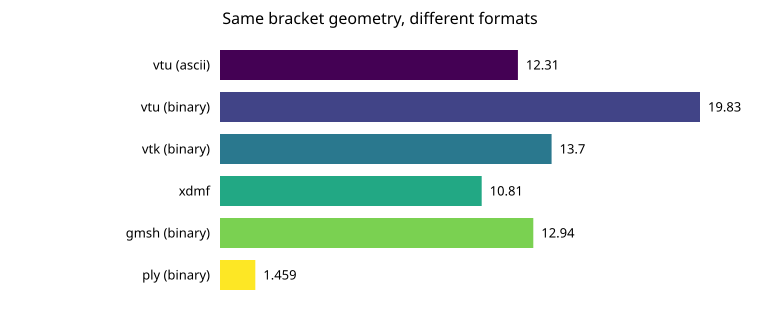

In [4]:
std::vector<std::string> labels;
for (auto& t : targets) labels.push_back(t.label);
xcpp::display(bar_chart(labels, sizes_mb, "Same bracket geometry, different formats", "viridis"));

## Round-trip verification

Read every file back (through the registry, which infers the reader from
each format name) and check the point/cell counts survive. `ply` is the
one expected exception: `write_ply`'s default `skin=true` deliberately
writes the extracted *linearized skin*, not the original triangle+tetra
blocks, so its round trip is compared against the skin instead.

In [5]:
std::size_t n_pts = mesh.NumPoints();
std::size_t n_cells = mesh.Cells(0).NumCells() + mesh.Cells(1).NumCells();
Mesh skin = extract_skin(mesh, /*linearize=*/true);

for (auto& t : targets) {
    Mesh back = registry_read(t.path, t.format, {});
    std::size_t bpts = back.NumPoints();
    std::size_t bcells = 0;
    for (std::size_t i = 0; i < back.NumCellBlocks(); ++i) bcells += back.Cells(i).NumCells();
    bool ply_case = (t.format == "ply");
    std::size_t expect_pts = ply_case ? skin.NumPoints() : n_pts;
    std::size_t expect_cells = ply_case ? skin.Cells(0).NumCells() : n_cells;
    bool ok = (bpts == expect_pts) && (bcells == expect_cells);
    std::cout << (ok ? "OK  " : "DIFF") << " " << std::left << std::setw(16) << t.label << std::right
              << " points=" << bpts << " cells=" << bcells << "\n";
}

OK   vtu (ascii)      points=52282 cells=293408
OK   vtu (binary)     points=52282 cells=293408
OK   vtk (binary)     points=52282 cells=293408
OK   xdmf             points=52282 cells=293408
OK   gmsh (binary)    points=52282 cells=293408
OK   ply (binary)     points=29151 cells=58394


Every format round-trips the geometry it is capable of carrying. For the
timing difference between meshio++ and the original pure-Python `meshio`,
see the [benchmarks](../benchmark/01_benchmark.ipynb) (those measure the
Python bindings; this notebook's C++ core is what they call into).